<a name="top" id="top"></a>

<div align="center">

<h1>PSO 3 — Individual exercise (graded): Step and pulse responses of a transfer function</h1>

<p>
  <a href="https://colab.research.google.com/github/SECQUOIA/PU_CHE456_F2026/blob/main/PSO3/PSO3_2_StepAndPulseResponse.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab">
  </a>
  <a href="https://secquoia.github.io/">
    <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA">
  </a>
</p>

</div>


## 🎯 Task

This is the graded exercise for PSO 3 (due **Friday 6:00 pm** on Brightspace). It uses exactly the tools from the guided notebook `PSO3_TransferFunctions.ipynb`.

Consider the process transfer function

$$G(s) = \frac{Y(s)}{U(s)} = \frac{2}{4s + 1}$$

1. Define $G(s)$ with the `control` package and print it.
2. Simulate and plot the response $y(t)$ to a **delayed step**: $u(t) = 3\,S(t-2)$, i.e., a step of magnitude 3 applied at $t = 2$ (build the input with a Heaviside function and use `forced_response`).
3. Simulate and plot the response to a **rectangular pulse** of height 3 lasting from $t = 2$ to $t = 7$.
4. From your plots, report: (a) the steady-state value reached after the step, and (b) the value the pulse response returns to. Compare (a) with the product $G(0) \times 3$, where $G(0)$ is the transfer function evaluated at $s = 0$ (the *steady-state gain*).

In [14]:
# If using this notebook in Google Colab, install python-control
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %pip install -q control==0.10.2

<TransferFunction>: sys[33]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     2
  -------
  4 s + 1


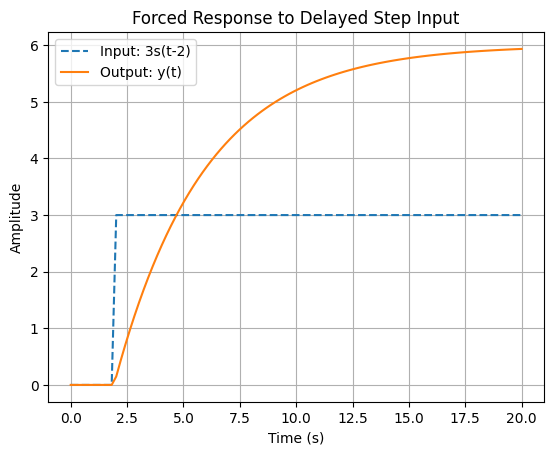

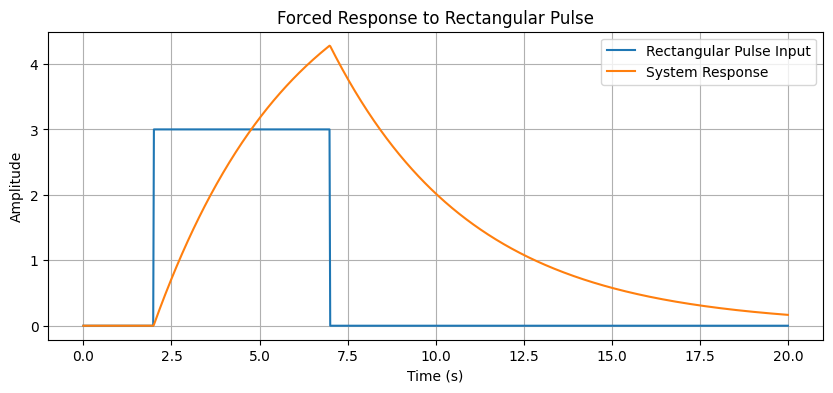

In [15]:
import numpy as np
import control as ctrl
import matplotlib.pyplot as plt

def heaviside(t, t0=0.0):
    """Unit step S(t - t0) on an array t."""
    return np.where(t >= t0, 1.0, 0.0)

# 1. define G(s) = 2 / (4s + 1) and print it

num = [2]
den = [4, 1]
system = ctrl.TransferFunction(num, den)
print(system)

# 2. time vector, delayed step input, forced_response, plot

# Step of magnitude 3 at t=2
T = np.linspace(0, 20, 100)
U = 3 * heaviside(T, 2)

# Compute the forced response
T, y= ctrl.forced_response(system, T, U)

# Plot input and output
plt.plot(T, U, '--', label='Input: 3s(t-2)')
plt.plot(T, y, label='Output: y(t)')
plt.title('Forced Response to Delayed Step Input')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

# 3. rectangular pulse input (difference of two Heaviside steps), forced_response, plot

# Define time array
T = np.linspace(0, 20, 1000)
pulse = 3* (np.heaviside(T-2, 1) - np.heaviside(T-7, 1))  # Pulse from t=2 to t=7

# Compute forced response of the system to the rectangular pulse input
T, y= ctrl.forced_response(system, T, pulse)

# Plot input and output
plt.figure(figsize=(10, 4))
plt.plot(T, pulse, label='Rectangular Pulse Input')
plt.plot(T, y, label='System Response')
plt.title('Forced Response to Rectangular Pulse')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

# 4. read the steady-state values off the simulations and compare with G(0)*3
# From your plots, report: (a) the steady-state value reached after the step,
# and (b) the value the pulse response returns to. Compare (a) with the product
# G(0)×3 , where  G(0)  is the transfer function evaluated at  s=0
# (the steady-state gain).

*Your written answers for part 4 here.*

a) Steady state after step = 6

b) Value Pulse Returns to  = 0

c) G(0) = 2, G(0) x 3 = 6. These values agree.

## 📬 Submission checklist

* Both plots have axis labels with units-style annotations (time, output), a title, and a grid.
* The notebook runs top to bottom without errors (`Kernel -> Restart & Run All`).
* Your part-4 comparison states both numbers explicitly.

---

## Authors

<div align="center">

<p>
<a href="https://github.com/bernalde"><strong>David E. Bernal Neira</strong></a><br>
<em>Davidson School of Chemical Engineering, Purdue University</em>
</p>

</div>